<div>
<a href="https://www.audiolabs-erlangen.de/fau/professor/mueller"><img src="data_layout/PCP_Teaser.png" width=100% style="float: right;" alt="PCP Teaser"></a>
</div>

# Unit 8: Signals and Sampling

<ul>
    <li><a href="#learn" style="color:#E65100;"><strong>Overview and Learning Objectives</strong></a></li>
    <li><a href="#signals" style="color:black;">Signals and Sinusoids</a></li>
    <li><a href="#audio" style="color:black;">Listening to Numerical Signals</a></li>
    <li><a href="#background_digital_audio" style="color:#1B5E20;"><strong>Background:</strong> From Sound Waves to Digital Audio</a></li>
    <li><a href="#sampling" style="color:black;">Sampling: From Continuous to Discrete Time</a></li>
    <li><a href="#background_sampling" style="color:#1B5E20;"><strong>Background:</strong> The Sampling Theorem and Perfect Reconstruction</a></li>
    <li><a href="#aliasing" style="color:black;">Aliasing</a></li>
    <li><a href="#interference" style="color:black;">Interference and Beating</a></li>
    <li><a href="#exercise_aliasing_sinus" style="color:#006064;"><strong>Exercise 1:</strong> Aliasing with Sinusoids</a></li>
    <li><a href="#exercise_sinc" style="color:#006064;"><strong>Exercise 2:</strong> Understanding Sinc Interpolation</a></li>
    <li><a href="#exercise_sound_design" style="color:#006064;"><strong>Exercise 3:</strong> Synthesizing a Plucked-String Sound</a></li>
</ul>

<a id="learn"></a>

<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">

<h2 style="color:#E65100; margin-top:0;">
Overview and Learning Objectives
</h2>

<p style="color:#E65100;">
A <strong>signal</strong> represents information through values that vary with time, space, or another independent variable. Examples include changing air pressure in sound, the brightness values of an image, and the sequence of images forming a video. In this unit, we focus on <strong>audio signals</strong>, which can be visualized as waveforms, stored as NumPy arrays, and reproduced through audio playback. We begin by constructing, displaying, and listening to <strong>sinusoidal signals</strong>. We then study <strong>sampling</strong>, which converts a continuous-time signal into a sequence of discrete values. This leads to the sampling theorem, sinc interpolation, and <strong>aliasing</strong>, where different continuous-time signals become indistinguishable after sampling. Finally, we examine <strong>interference</strong> and <strong>beating</strong>, connecting the addition of sinusoids to visible and audible effects. After completing this unit, you should be able to:
</p>

<ul style="color:#E65100;">
<li>Distinguish between continuous-time and discrete-time signals.</li>
<li>Generate, visualize, and play sinusoidal signals with specified parameters.</li>
<li>Relate the sampling period to the sampling rate and explain the main idea of the sampling theorem.</li>
<li>Explain how sinc interpolation reconstructs a signal from its samples.</li>
<li>Recognize aliasing and explain why sampling may lose information.</li>
<li>Explain constructive and destructive interference and the origin of beating.</li>
<li>Combine sinusoids, amplitude envelopes, noise, and transients to synthesize simple sounds.</li>
</ul>

<p style="color:#E65100;">
The unit contains three exercises:
</p>

<ul style="color:#E65100;">
<li><a href="#exercise_aliasing_sinus">Exercise 1</a>: Explore aliasing with sinusoids.</li>
<li><a href="#exercise_sinc">Exercise 2</a>: Understand reconstruction through sinc interpolation.</li>
<li><a href="#exercise_sound_design">Exercise 3</a>: Synthesize a plucked-string sound from simple signal components.</li>
</ul>

<p style="color:#E65100; margin-bottom:0;">
Related material is available in the <a href="https://www.audiolabs-erlangen.de/FMP">FMP Notebooks</a>, particularly the notebooks on <a href="https://www.audiolabs-erlangen.de/resources/MIR/FMP/C2/C2S2_DigitalSignalSampling.html">digital signal sampling</a> and <a href="https://www.audiolabs-erlangen.de/resources/MIR/FMP/C2/C2S3_InterferenceBeating.html">interference and beating</a>, which provided a basis for parts of this unit.
</p>

In [1]:
# --- Core scientific stack ---
import numpy as np
from matplotlib import pyplot as plt
import IPython.display as ipd

# --- Custom utilities (Unit 8) ---
from libpcp.unit08 import (
    exercise_aliasing_sinus,
    exercise_sinc,
    exercise_sound_design,
)

# --- Figure format and font size settings ---
%config InlineBackend.figure_formats = ['svg']
plt.rcParams.update({'font.size': 8, 'axes.titlesize': 9})

<a id="signals"></a>
## Signals and Sinusoids

A **signal** is a function that assigns a value to each permitted value of an independent variable. In this unit, that variable is time. A real-valued **continuous-time signal** can therefore be written as

$$
f:\mathbb{R}\to\mathbb{R},
\qquad
t\mapsto f(t),
$$

where $t\in\mathbb{R}$ denotes time and $f(t)\in\mathbb{R}$ is the corresponding signal value. For an acoustic signal, $f(t)$ may represent the deviation of the air pressure from a reference pressure. Positive and negative values then indicate pressure above and below this reference level. An important example is the **sinusoidal signal**

$$
f(t):=A\sin\bigl(2\pi(\omega t-\varphi)\bigr),
\qquad t\in\mathbb{R}.
$$

Its behavior is determined by three parameters:

* The **amplitude** $A\geq0$ determines the largest absolute signal value.
* The **frequency** $\omega>0$, measured in hertz (Hz), specifies the number of oscillations per second. One oscillation therefore lasts $1/\omega$ seconds.
* The **phase** $\varphi$ determines the position of the oscillation within one cycle.

The factor $2\pi$ converts cycles into angles measured in radians. We use the normalized phase $\varphi\in[0,1)$, where $1$ corresponds to one complete cycle. Thus, $\varphi=1/4$ shifts the sinusoid by one quarter of a cycle. Equivalently, phase could be expressed as an angle in $[0,2\pi)$ and measured directly in radians.

The mathematical function $f$ is defined at every real time, but a computer can store only finitely many values. For a numerical representation, we choose a **duration** and evaluate the function at equally spaced time points determined by a **sampling rate**. The resulting time points and signal values are stored in NumPy arrays. This is already a form of sampling, which we will examine carefully later. The following code defines one function for generating this numerical representation and another for plotting it. The markers indicate the stored values, while the connecting lines help reveal the shape of the sinusoid:

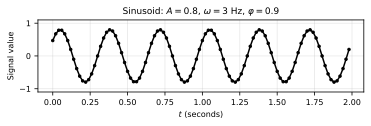

In [2]:
def generate_sinusoid(dur=1, amp=1, freq=1, phase=0, sr=4000):
    """Generate a sampled sinusoid."""
    t = np.arange(int(dur * sr)) / sr
    x = amp * np.sin(2 * np.pi * (freq * t - phase))
    return x, t, sr

def plot_signal(x, t, title='Signal', show_samples=False,
                figsize=(5.2, 1.8), color='black'):
    """Plot a signal over time."""
    marker = 'o' if show_samples else None
    plt.figure(figsize=figsize, layout='tight')
    plt.plot(t, x, color=color, marker=marker, markersize=2.5)
    plt.xlabel('$t$ (seconds)')
    plt.ylabel('Signal value')
    plt.title(title)
    plt.grid(alpha=0.3)

dur, amp, freq, phase = 2, 0.8, 3, 0.9
x, t, sr = generate_sinusoid(dur=dur, amp=amp, freq=freq, phase=phase, sr=50)
title = rf'Sinusoid: $A={amp}$, $\omega={freq}$ Hz, $\varphi={phase}$'
plot_signal(x, t, title=title, show_samples=True)
plt.ylim(-1.1, 1.1);

In this example, the two-second interval is represented by $100$ stored values. At a frequency of $3$ Hz, the signal completes six oscillations, with approximately $17$ samples per cycle. The markers show the stored values, while the connecting line helps reveal the sinusoidal shape but does not represent additional samples. By changing the arguments of `generate_sinusoid()`, we can independently control the amplitude, frequency, phase, duration, and numerical resolution of the signal.

<a id="audio"></a>
## Listening to Numerical Signals

A NumPy array contains an ordered sequence of values, but it does not specify how much physical time passes between them. For audio playback, the array must therefore be combined with a **sampling rate**, commonly abbreviated as `sr`. For example, audio CDs use $44\,100$ samples per second, a rate widely used for high-quality audio.

The previous frequency of $3$ Hz is too low to be perceived as a musical pitch. We therefore generate a two-second sinusoid at $440$ Hz, corresponding to the musical note A4, with amplitude $0.2$ and a sampling rate of $4000$ Hz. This rate is sufficient for our example and keeps the array small: it contains $2\cdot4000=8000$ values ranging from $-0.2$ to $0.2$.

The function `generate_sinusoid()` returns the signal values, their corresponding time points, and the sampling rate. In the following call, `_` indicates that the time array is not needed. The function `ipd.Audio()` then creates an audio player from the signal values, while its keyword argument `rate` specifies how many samples are played per second:

In [3]:
sr = 4000

# Generate two seconds of the pitch A4
x_audio, _, sr = generate_sinusoid(dur=2, amp=0.2, freq=440, phase=0, sr=sr)

# Play the signal at 4000 samples per second
ipd.Audio(x_audio, rate=sr, normalize=False)

The array determines the waveform, while the sampling rate determines how quickly its values are played. The following background box places this small Python example in the broader process of recording, storing, and reproducing sound.

<a id="background_digital_audio"></a>
<div style="
  background-color: #C8E6C9A0;
  border: 1px solid #81C784A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">

<h2 style="color:#1B5E20; margin-top:0;">
Background: From Sound Waves to Digital Audio
</h2>

<div style="
  float:right;
  width:230px;
  max-width:42%;
  margin-left:20px;
  margin-bottom:10px;
">
<img src="data/PCP_fig_wave_longitudal.png"
     style="display:block; width:100%; height:auto;"
     alt="Sound wave with regions of high and low air pressure">
</div>

<p style="color:#1B5E20;">
Sound begins with a vibrating object, such as the vocal folds of a singer, a violin string, or a loudspeaker membrane. The vibration moves nearby air molecules back and forth, creating regions of higher and lower density and pressure, as shown in the figure. This changing pressure travels through the air as a <strong>sound wave</strong>, while the individual molecules mainly oscillate around their local positions. In this respect, sound resembles a stadium wave: the pattern moves forward, although the people creating it remain near their seats. The figure shows the wave across space at one moment. A microphone records another view by measuring the pressure at one fixed position over time. Plotting these values produces a <strong>waveform</strong>, which shows the pressure deviation from its average level. The microphone converts these changes into a continuously varying electrical signal.
</p>

<p style="color:#1B5E20;">
Before a computer can store this signal, it must be converted into finitely many numbers. <strong>Sampling</strong> measures its value at regularly spaced moments, replacing continuous time with discrete time points. <strong>Quantization</strong> assigns each measurement to one of finitely many levels, replacing continuous amplitudes with discrete values. The <strong>sampling rate</strong> specifies the number of measurements per second, while the <strong>bit depth</strong> determines how many levels are available. An <a href="https://en.wikipedia.org/wiki/Compact_Disc_Digital_Audio">audio CD</a>, for example, uses $44\,100$ samples per second, $16$ bits per sample, and two stereo channels. This produces $44\,100\cdot16\cdot2=1\,411\,200$ bits, or about $1.41$ megabits, per second. One hour of uncompressed audio therefore requires approximately $635$ megabytes, and a conventional audio CD typically holds about $74$ to $80$ minutes of music.
</p>

<p style="color:#1B5E20; margin-bottom:0;">
During <strong>playback</strong>, the process is reversed: the stored numbers become an electrical signal, and a loudspeaker turns it back into changing air pressure. The sampling rate determines how quickly the values are played. A higher rate makes the sound shorter and raises its frequencies; a lower rate makes it longer and lowers them. Under suitable conditions, the CD sampling rate can represent frequencies below $22\,050$ Hz, slightly above the commonly stated upper limit of human hearing near $20\,000$ Hz. We will explain this relationship through the sampling theorem. Although speech and music are far more complex than a single sinusoid, sinusoids remain useful building blocks for understanding them.    
</p>

<div style="clear:both;"></div>
</div>

Having seen how sound is represented digitally, let us explore **pitch**, the perceptual attribute that orders tones from low to high. For pure sinusoids, pitch is closely related to frequency. In scientific pitch notation, the letter names the note and the number identifies its **octave**. The reference pitch A4, also known as **concert pitch**, has a frequency of $440$ Hz; A3 and A5 have frequencies of $220$ and $880$ Hz. Thus, doubling or halving the frequency preserves the note name while shifting the pitch by one octave. Listen to these three versions of A:


In [4]:
sr = 4000

# Generate and play the note A in three neighboring octaves
for note, freq in [('A3', 220), ('A4', 440), ('A5', 880)]:
    x_audio, _, sr = generate_sinusoid(amp=0.2, freq=freq, sr=sr)
    print(f'{note}: {freq} Hz')
    ipd.display(ipd.Audio(x_audio, rate=sr, normalize=False))

A3: 220 Hz


A4: 440 Hz


A5: 880 Hz


Two sounds can have the same pitch and still sound very different. A sinusoid contains only one frequency and is therefore perceived as a **pure tone**. Musical instruments usually produce a fundamental frequency together with weaker oscillations at integer multiples of it, called **harmonics**. The fundamental largely determines the pitch, while the number and relative strengths of the harmonics contribute to the **timbre**, or tone color. The following simplified signals all have the fundamental frequency $220$ Hz but different harmonic mixtures:

In [5]:
sr = 4000
freq = 220  # Fundamental frequency of A3

# Pure tone containing only the fundamental
x_pure, _, _ = generate_sinusoid(amp=0.2, freq=freq, sr=sr)

# Add the first five harmonics with decreasing amplitudes
x_harmonic = sum(
    generate_sinusoid(amp=0.15 / k, freq=freq * k, sr=sr)[0]
    for k in range(1, 6)
)

# Retain only the first three odd harmonics
x_odd_harmonic = sum(
    generate_sinusoid(amp=0.18 / k, freq=freq * k, sr=sr)[0]
    for k in [1, 3, 5]
)

for label, signal in [
    ('Pure A3', x_pure),
    ('A3 with five harmonics', x_harmonic),
    ('A3 with odd harmonics', x_odd_harmonic),
]:
    print(label)
    ipd.display(ipd.Audio(signal, rate=sr, normalize=False))

Pure A3


A3 with five harmonics


A3 with odd harmonics


Real sounds are usually far more complex than a single sinusoid. Several pitched tones may occur at the same time and combine to create **harmony**. A selected group of simultaneous notes forms a **chord**, while several independent melodic lines produce **polyphonic music**. Even one note played by a real instrument typically contains many frequencies and changes over time. Not every sound has a clear pitch or a regularly repeating waveform. **Noise** contains irregular changes and may resemble the sound of wind or a waterfall. In Gaussian noise, the signal values are chosen randomly according to a normal distribution. Other sounds are defined by their short duration: clicks, hand claps, and drum attacks appear suddenly and disappear quickly. Such brief events are called **transients**. We conclude our audio exploration with three contrasting signals: a C-major chord, Gaussian noise, and a single click. They range from musical harmony to an irregular rushing sound and finally to one isolated event, yet Python represents all three in the same way as NumPy arrays.

In [6]:
sr = 4000

# Add three sinusoids to form a C-major chord
chord_freqs = [261.63, 329.63, 392.00]
x_chord = sum(
    generate_sinusoid(dur=1, amp=0.08, freq=freq, sr=sr)[0]
    for freq in chord_freqs
)

# Generate one second of reproducible Gaussian noise
rng = np.random.default_rng(0)
x_noise = 0.05 * rng.standard_normal(sr)

# Create a single impulse after half a second
x_click = np.zeros(sr)
x_click[sr // 2] = 0.8

# Play the three signals without automatic normalization
for label, signal in [
    ('C-major chord', x_chord),
    ('Gaussian noise', x_noise),
    ('Single click', x_click),
]:
    print(label)
    ipd.display(ipd.Audio(signal, rate=sr, normalize=False))

C-major chord


Gaussian noise


Single click


<a id="sampling"></a>
## Sampling: From Continuous to Discrete Time

As described in the background box on <a href="#background_digital_audio">sound waves and digital audio</a>, sampling converts a continuously varying signal into a sequence of measurements. We now formulate this process mathematically and examine how the resulting discrete-time signal relates to the original continuous-time signal. Let $f:\mathbb{R}\to\mathbb{R}$ be a continuous-time signal. In **uniform sampling**, its values are measured at the equally spaced time points

$$
t_n:=nT,
\qquad n\in\mathbb{Z},
$$

where $T>0$ is the **sampling period**, measured in seconds. The resulting **discrete-time signal** $x:\mathbb{Z}\to\mathbb{R}$ is defined by

$$
x(n):=f(t_n)=f(nT),
\qquad n\in\mathbb{Z}.
$$

Thus, $f$ is defined for every real time $t\in\mathbb{R}$, whereas $x$ is defined only at integer sample indices $n\in\mathbb{Z}$. The reciprocal of the sampling period,

$$
F_{\mathrm{s}}:=\frac{1}{T},
$$

is the **sampling rate**, measured in hertz. It specifies the number of samples taken per second. For example, $F_{\mathrm{s}}=100$ Hz corresponds to a sampling period of $T=1/100=0.01$ seconds. The mathematical sequence $x$ may be defined for all integers, but an actual recording has a **finite duration**. A signal of duration $D$ seconds sampled at $F_{\mathrm{s}}$ Hz contains approximately $N=DF_{\mathrm{s}}$ values, indexed by $n=0,\ldots,N-1$. Their physical time positions are $t_n=n/F_{\mathrm{s}}$. Sampling discretizes time but does not restrict the possible signal values; restricting amplitudes to finitely many levels is the separate process of **quantization**.

To illustrate sampling, we combine three sinusoids with frequencies $1.9$, $6.1$, and $16$ Hz and decreasing amplitudes. The mixture therefore contains both slowly and rapidly changing components. Since a computer cannot store a genuinely continuous-time signal, we first evaluate the function at $100$ Hz and use the resulting array as a dense numerical reference. The function `sampling_equidistant()` then evaluates an interpolation of this reference at a new set of equally spaced time points. In the following code cell, a two-second reference signal sampled at $100$ Hz contains $200$ values. Sampling it at $F_{\mathrm{s}}=20$ Hz retains only $40$ values. The upper subplot displays the dense reference as an approximation of the continuous-time signal, while the lower subplot shows the retained samples at their physical time positions. The dotted curve indicates where these samples lie relative to the reference:

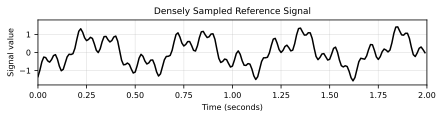

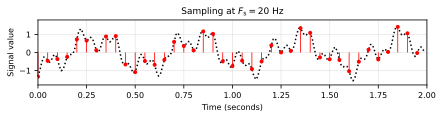

In [7]:
def generate_example_signal(dur=1, sr=100):
    """Generate the example signal."""
    N = int(round(sr * dur))
    t = np.arange(N) / sr
    x =  0.8 * np.sin(2 * np.pi * (1.9 * t - 0.3))
    x += 0.5 * np.sin(2 * np.pi * (6.1 * t - 0.1))
    x += 0.3 * np.sin(2 * np.pi * (16 * t - 0.2))
    return x, t


def sampling_equidistant(x_ref, t_ref, sr, dur=None):
    """Sample an interpolated reference signal at equally spaced times."""
    if dur is None:
        dur = t_ref[-1] + t_ref[1] - t_ref[0]
    N = int(round(sr * dur))
    t = np.arange(N) / sr
    x = np.interp(t, t_ref, x_ref)
    return x, t


dur = 2
x_ref, t_ref = generate_example_signal(dur=dur, sr=100)
x, t = sampling_equidistant(x_ref, t_ref, sr=20)

# Densely sampled reference
plt.figure(figsize=(6.2, 1.7), layout='tight')
plt.plot(t_ref, x_ref, color='black')
plt.title('Densely Sampled Reference Signal')
plt.xlabel('Time (seconds)')
plt.ylabel('Signal value')
plt.xlim(0, dur)
plt.ylim(-1.8, 1.8)
plt.grid(alpha=0.3)

# Signal sampled at 20 Hz
plt.figure(figsize=(6.2, 1.7), layout='tight')
plt.plot(t_ref, x_ref, color='black', linestyle=':')
markers, stems, _ = plt.stem(t, x, linefmt='r-', markerfmt='ro', basefmt=' ')
markers.set_markersize(3)
stems.set_linewidth(0.8)
plt.title(r'Sampling at $F_\mathrm{s}=20$ Hz')
plt.xlabel('Time (seconds)')
plt.ylabel('Signal value')
plt.xlim(0, dur)
plt.ylim(-1.8, 1.8)
plt.grid(alpha=0.3)

<a id="background_sampling"></a>
<div style="
  background-color: #C8E6C9A0;
  border: 1px solid #81C784A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">

<h2 style="color:#1B5E20; margin-top:0;">
Background: The Sampling Theorem and Perfect Reconstruction
</h2>

<p style="color:#1B5E20;">
The preceding example retained only $40$ of the $200$ reference values. Without additional assumptions, sampling is a <strong>lossy</strong> operation: the samples provide no direct information about the signal between the sampling times, and infinitely many continuous-time signals may pass through the same points. The classical sampling theorem considers <strong>bandlimited</strong> signals, which contain no frequency components above some limit $B$. This concept will become clearer when we study frequency content and the Fourier transform in <a href="PCP_09_dft.html">Unit 9</a>. Let $f:\mathbb{R}\to\mathbb{R}$ be bandlimited to $B$ Hz and sampled with period $T$ and rate $F_{\mathrm{s}}=1/T$. The <strong>sampling theorem</strong> states that $f$ can be reconstructed perfectly from $x(n)=f(nT)$ if
$$
F_{\mathrm{s}}>2B.
$$
Thus, the sampling rate must exceed twice the highest frequency in the signal. The value $2B$ is called the <strong>Nyquist rate</strong>, while $F_{\mathrm{s}}/2$ is the <strong>Nyquist frequency</strong>. Under these ideal conditions, the signal can be recovered through <strong>sinc interpolation</strong>:
$$
f(t)=\sum_{n\in\mathbb{Z}}
x(n)\operatorname{sinc}\left(\frac{t-nT}{T}\right),
\qquad
\operatorname{sinc}(t):=
\begin{cases}
\dfrac{\sin(\pi t)}{\pi t}, & t\neq0,\\[4pt]
1, & t=0.
\end{cases}
$$
Each sample scales a sinc function centered at its sampling time. This function has value $1$ at its center and $0$ at all other sampling times. Adding the shifted sinc functions therefore reproduces every sample while filling in the values between them.
</p>

<p style="color:#1B5E20; margin-bottom:0;">
The theorem explains why audio intended to represent frequencies up to approximately $20\,000$ Hz requires a sampling rate above $40\,000$ Hz; the CD rate of $44\,100$ Hz meets this condition. In our numerical example, the highest frequency is $16$ Hz. The reference rate of $100$ Hz satisfies $100>2\cdot16$, whereas the sampling rate of $20$ Hz does not. Perfect reconstruction remains an ideal mathematical result because real recordings are finite and may contain noise or frequencies beyond the assumed limit. If the sampling condition is violated, different continuous-time signals may produce the same samples. This loss of information is called <strong>aliasing</strong>.
</p>

</div>

<a id="aliasing"></a>
## Aliasing

Let us return to the third sinusoidal component of the preceding example:

$$
f_3(t):=0.3\sin\bigl(2\pi(16t-0.2)\bigr),
\qquad t\in\mathbb{R}.
$$

This sinusoid has a frequency of $16$ Hz. Sampling it at $F_{\mathrm{s}}=16$ Hz means taking exactly one sample per oscillation at the times $t_n=n/16$. The resulting discrete-time component is

$$
x_3(n):=f_3\left(\frac{n}{16}\right)
=0.3\sin\bigl(2\pi(n-0.2)\bigr)
=0.3\sin(-0.4\pi).
$$

The value is therefore the same for every integer $n$. The original signal continues to oscillate, but every sample observes it at exactly the same phase. As a result, the $16$ Hz component appears constant in the sampled signal. This ambiguity occurs more generally. Consider the sinusoid $g_\omega(t):=\sin\bigl(2\pi(\omega t-\varphi)\bigr)$ and another sinusoid whose frequency differs by an integer multiple of the sampling rate. For any $k,n\in\mathbb{Z}$,

$$
\begin{aligned}
g_{\omega+kF_{\mathrm{s}}}\left(\frac{n}{F_{\mathrm{s}}}\right)
&=\sin\left(2\pi\left(
\omega\frac{n}{F_{\mathrm{s}}}-\varphi\right)+2\pi kn\right)\\
&=\sin\left(2\pi\left(
\omega\frac{n}{F_{\mathrm{s}}}-\varphi\right)\right)\\
&=g_\omega\left(\frac{n}{F_{\mathrm{s}}}\right).
\end{aligned}
$$


Although the continuous-time frequencies are different, their sampled values are identical. The term **aliasing** refers to this ambiguity: after sampling, different continuous-time signals can become indistinguishable. A misleading frequency that appears in place of the original one is called an **alias**. Depending on the sampling rate, a fast oscillation may appear slower or may even seem to run backward. The same effect can be seen in films when the wheels of a moving car appear to rotate slowly or in the wrong direction: each video frame is a sample in time, and the camera may repeatedly capture the wheel at misleading positions.

To make aliasing visible, we reconstruct the signal from its samples using the **sinc interpolation** formula introduced in the <a href="#background_sampling">background box</a>. The reconstructed signal passes through every sample, but this does not guarantee that it matches the original signal. After aliasing has occurred, the samples can no longer distinguish the original high-frequency components from their lower-frequency aliases. Sinc interpolation therefore produces a smooth and plausible signal that agrees with all available samples but may still be the wrong signal.

The following figures show the densely sampled reference as a dotted black curve, the samples in red, and the sinc reconstruction in blue. The highest signal frequency is $B=16$ Hz. At $F_{\mathrm{s}}=40$ Hz, the sampling condition $F_{\mathrm{s}}>2B$ is satisfied because $40>32$, and the reconstruction closely agrees with the reference. At $F_{\mathrm{s}}=20$ Hz, this condition is violated, and the smooth reconstructed signal already differs substantially from the original. Reducing the rate further to $F_{\mathrm{s}}=10$ Hz causes additional high-frequency components to appear as aliases, increasing the difference between the reconstruction and the reference.

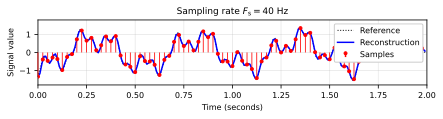

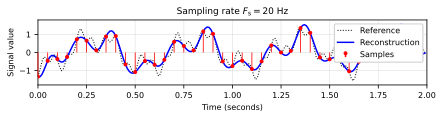

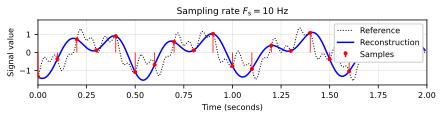

In [8]:
def reconstruction_sinc(x, t, t_rec):
    """Reconstruct a sampled signal using sinc interpolation."""
    sr = 1 / (t[1] - t[0])
    x_rec = np.zeros_like(t_rec)
    for n, value in enumerate(x):
        x_rec += value * np.sinc(sr * t_rec - n)
    return x_rec


def plot_reconstruction(x_ref, t_ref, x, t, x_rec, figsize=(6.2, 1.7)):
    """Plot a reference, sampled, and reconstructed signal."""
    sr = 1 / (t[1] - t[0])
    dur = t_ref[-1] + t_ref[1] - t_ref[0]

    plt.figure(figsize=figsize, layout='tight')
    plt.plot(t_ref, x_ref, 'k:', linewidth=1,
             label='Reference')
    markers, stems, _ = plt.stem(
        t, x, linefmt='r-', markerfmt='ro',
        basefmt=' ', label='Samples'
    )
    markers.set_markersize(3)
    stems.set_linewidth(0.8)
    markers.set_zorder(3)
    stems.set_zorder(3)
    plt.plot(t_ref, x_rec, color='blue', label='Reconstruction')
    plt.title(rf'Sampling rate $F_\mathrm{{s}}={sr:g}$ Hz')
    plt.xlabel('Time (seconds)')
    plt.ylabel('Signal value')
    plt.xlim(0, dur)
    plt.ylim(-1.8, 1.8)
    plt.grid(alpha=0.3)
    plt.legend(loc='upper right', framealpha=1)
    plt.show()


for sr_sampled in [40, 20, 10]:
    x, t = sampling_equidistant(x_ref, t_ref, sr=sr_sampled)
    x_rec = reconstruction_sinc(x, t, t_ref)
    plot_reconstruction(x_ref, t_ref, x, t, x_rec)

<a id="interference"></a>

## Interference and Beating

Aliasing concerns how sampling can change the apparent behavior of a signal. We now return to the signals themselves and ask what happens when several signals occur at the same time. We already used this idea when constructing a C-major chord by adding three sinusoids. In general, the **superposition** of two continuous-time signals $f_1$ and $f_2$ is their pointwise sum

$$
f(t):=f_1(t)+f_2(t),
\qquad t\in\mathbb{R}.
$$

The same principle applies to discrete-time signals: their values are added at each sample index. Depending on their frequencies and phases, two signals may reinforce or cancel each other. This interaction is called **interference**.

If both signals have large positive values at the same time, they add to produce an even larger positive value. Similarly, if both have large negative values at the same time, their sum becomes even more negative. This reinforcement is called **constructive interference**. In contrast, if one signal has a positive value while the other has a negative value of similar magnitude, their values cancel partially or completely, producing **destructive interference**. The following examples plot two sinusoids together with their superposition, making both effects visible:

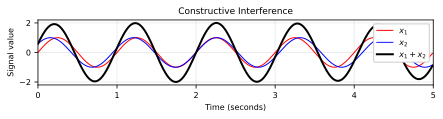

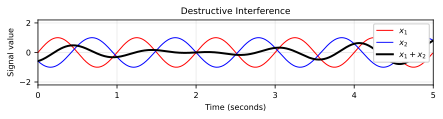

In [9]:
def plot_interference(t, x1, x2, xlim=None, ylim=None,
                      title='', lwf=1, figsize=(6.2, 1.7)):
    """Plot two signals and their superposition."""
    plt.figure(figsize=figsize, layout='tight')
    plt.plot(t, x1, color='red', linewidth=1*lwf, label='$x_1$')
    plt.plot(t, x2, color='blue', linewidth=1*lwf, label='$x_2$')
    plt.plot(t, x1 + x2, color='black', linewidth=2*lwf, label='$x_1+x_2$')
    plt.xlabel('Time (seconds)')
    plt.ylabel('Signal value')
    plt.title(title)
    plt.xlim(xlim if xlim is not None else (t[0], t[-1]))
    if ylim is not None:
        plt.ylim(ylim)
    plt.grid(alpha=0.3)
    plt.legend(loc='upper right', framealpha=1)
    plt.show()


dur, sr = 5, 100
x1, t, _ = generate_sinusoid(dur=dur, freq=1.00, phase=0, sr=sr)

title='Constructive Interference'
x2, _, _ = generate_sinusoid(dur=dur, freq=0.95, phase=0.9, sr=sr)
plot_interference(t, x1, x2, title=title, xlim=(0, dur), ylim=(-2.2, 2.2))

title='Destructive Interference'
x2, _, _ = generate_sinusoid(dur=dur, freq=0.95, phase=0.4, sr=sr)
plot_interference(t, x1, x2, title=title, xlim=(0, dur), ylim=(-2.2, 2.2))

The preceding figures show that interference depends on how the two signals align. When two sinusoids have slightly different frequencies, their relative alignment changes continuously: sometimes they reinforce each other, and sometimes they nearly cancel. The amplitude of their sum therefore rises and falls periodically. This phenomenon is called **beating**. To describe it mathematically, consider two sinusoids with frequencies $\omega_1$ and $\omega_2$:

$$
f_1(t):=\sin(2\pi\omega_1t),
\qquad
f_2(t):=\sin(2\pi\omega_2t).
$$

A trigonometric identity rewrites their superposition as

$$
\begin{aligned}
f_1(t)+f_2(t)
&=\sin(2\pi\omega_1t)+\sin(2\pi\omega_2t)\\
&=2\cos\bigl(\pi(\omega_1-\omega_2)t\bigr)
  \sin\bigl(\pi(\omega_1+\omega_2)t\bigr).
\end{aligned}
$$

This form reveals two different time scales. The sine factor produces the rapid oscillation at the average frequency

$$
\omega_{\mathrm{avg}}
:=\frac{\omega_1+\omega_2}{2},
$$

while the more slowly varying cosine factor controls its amplitude. When $\omega_1$ and $\omega_2$ are close, the result therefore resembles a tone at their average frequency whose loudness repeatedly increases and decreases. The cosine factor itself has frequency $|\omega_1-\omega_2|/2$. However, both its positive and negative peaks produce a large signal amplitude, so the perceived loudness reaches a maximum twice during each cosine cycle. The resulting **beat frequency** is

$$
\omega_{\mathrm{beat}}:=|\omega_1-\omega_2|.
$$

For example, tones at $200$ Hz and $203$ Hz differ by $3$ Hz and therefore produce three beats per second. The following code first makes this alternation between constructive and destructive interference visible at low frequencies and then demonstrates it with an audible example:


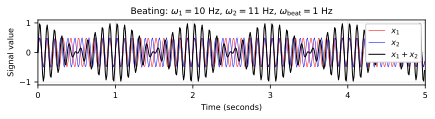

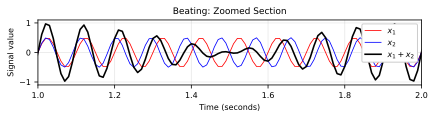

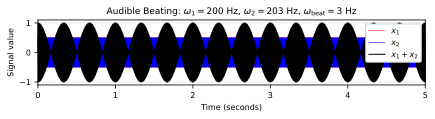

In [10]:
# Make beating visible at low frequencies
sr, dur = 100, 5
freq_1, freq_2 = 10, 11
x1, t, _ = generate_sinusoid(dur=dur, amp=0.5, freq=freq_1, sr=sr)
x2, _, _ = generate_sinusoid(dur=dur, amp=0.5, freq=freq_2, sr=sr)

title = (rf'Beating: $\omega_1={freq_1}$ Hz, $\omega_2={freq_2}$ Hz, '
         rf'$\omega_\mathrm{{beat}}={abs(freq_2-freq_1)}$ Hz')
plot_interference(t, x1, x2, xlim=(0, dur), ylim=(-1.1, 1.1),
                  title=title, lwf=0.5)
plot_interference(t, x1, x2, xlim=(1, 2), ylim=(-1.1, 1.1),
                  title='Beating: Zoomed Section', lwf=0.8)

# Make beating audible
sr, dur = 4000, 5
freq_1, freq_2 = 200, 203
x1, t, _ = generate_sinusoid(dur=dur, amp=0.5, freq=freq_1, sr=sr)
x2, _, _ = generate_sinusoid(dur=dur, amp=0.5, freq=freq_2, sr=sr)

title = (rf'Audible Beating: $\omega_1={freq_1}$ Hz, '
         rf'$\omega_2={freq_2}$ Hz, '
         rf'$\omega_\mathrm{{beat}}={abs(freq_2-freq_1)}$ Hz')
plot_interference(t, x1, x2, xlim=(0, dur), ylim=(-1.1, 1.1),
                  title=title, lwf=0.5)

ipd.Audio(x1 + x2, rate=sr, normalize=False)

Beating has an important practical use in **tuning** musical instruments. A guitarist may compare a reference pitch with the same pitch played on a string. Alternatively, the guitarist may produce the same pitch on two neighboring strings, such as at the fifth fret of the low E string and on the open A string. If the two frequencies differ slightly, the combined sound pulsates. As the tuning is adjusted, the beating becomes slower; when the frequencies agree, it disappears. The frequency difference in the formula above thus becomes something a musician can hear directly. This is a beautiful example of mathematics explaining a technique that musicians use in practice.

<a id="exercise_aliasing_sinus"></a>

<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding: 10px 20px;
  margin: 10px 0;
">

<strong style="color:#006064; display:block; break-after:avoid; page-break-after:avoid;">Exercise 1: Aliasing with Sinusoids</strong>

<p style="color:#006064;">
Generate a sinusoid of frequency $\omega=9.99$ Hz and duration $D=2$ seconds at a sampling rate of $128$ Hz to obtain a dense numerical reference:
</p>

<p style="color:#006064; text-align:center;">
<code>x_ref, t_ref, _ = generate_sinusoid(dur=2, freq=9.99, sr=128)</code>
</p>

<p style="color:#006064; margin-bottom:0;">
Use <code>sampling_equidistant()</code> to sample the reference at the rates <code>[64, 32, 20, 16, 12, 8, 4]</code>. For each rate, reconstruct and plot the signal using <code>reconstruction_sinc()</code> and <code>plot_reconstruction()</code>. Compare the result with the reference and relate your observations to the sampling condition $F_{\mathrm{s}}>2B$, where $B=9.99$ Hz. Pay particular attention to $F_{\mathrm{s}}=20$ Hz, which lies only slightly above the theoretical limit, and identify the aliases produced at lower sampling rates.
</p>

</div>


In [11]:
# Your Solution

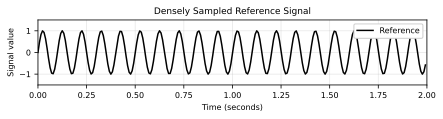

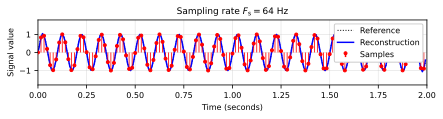

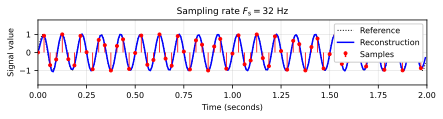

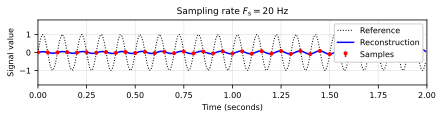

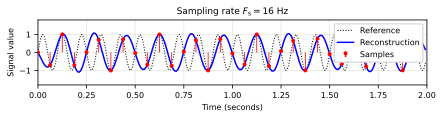

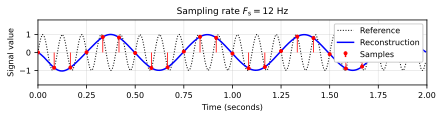

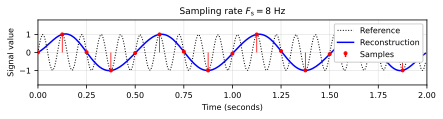

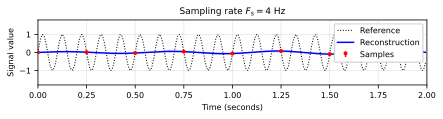

In [12]:
exercise_aliasing_sinus()

<a id="exercise_sinc"></a>

<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding: 10px 20px;
  margin: 10px 0;
">

<strong style="color:#006064; display:block; break-after:avoid; page-break-after:avoid;">Exercise 2: Understanding Sinc Interpolation</strong>

<p style="color:#006064;">
As explained in the <a href="#background_sampling">background box on the sampling theorem</a>, a bandlimited signal can be reconstructed from its samples using
$$
f(t)=\sum_{n\in\mathbb{Z}}
x(n)\operatorname{sinc}\left(\frac{t-nT}{T}\right),
\qquad
\operatorname{sinc}(t):=
\begin{cases}
\dfrac{\sin(\pi t)}{\pi t}, & t\neq0,\\[4pt]
1, & t=0.
\end{cases}
$$
The key property is $\operatorname{sinc}(0)=1$, while $\operatorname{sinc}(k)=0$ for every nonzero integer $k$. Each shifted sinc function therefore reproduces its sample at its own sampling time and vanishes at all the other sampling times. This is the simple trick behind <strong>sinc interpolation</strong>.
</p>

<p style="color:#006064;">
Let $T=1$ and consider the samples
$\bigl(x(0),x(1),x(2),x(3),x(4)\bigr)=(0,\;1,\;-0.5,\;0.75,\;0)$, with $x(n)=0$ for all other integers $n$. The sinc reconstruction therefore reduces to
$$
f_{\mathrm{rec}}(t)
:=\sum_{n=0}^{4}x(n)\operatorname{sinc}(t-n).
$$
</p>

<ol style="color:#006064; margin-bottom:0;">
<li><strong>Explore the sinc function:</strong> Plot <code>np.sinc(t)</code> over $[-4,4]$ and mark its values at the integers.</li>

<li><strong>Construct the interpolation:</strong> Plot the five terms $x(n)\operatorname{sinc}(t-n)$ and their sum. Mark the samples and verify numerically that $f_{\mathrm{rec}}(n)=x(n)$.</li>

<li><strong>Change one sample:</strong> Replace $x(2)=-0.5$ by $x(2)=0.5$ and compare the original and modified reconstructions. Observe how this single change affects the entire curve.</li>
</ol>

</div>

In [13]:
# Your Solution

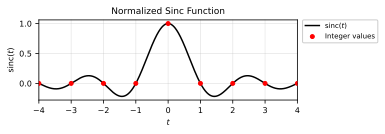

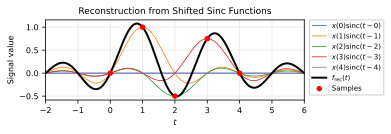

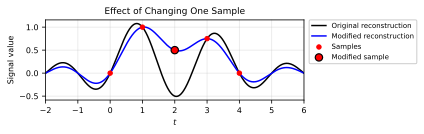

In [14]:
exercise_sinc()

<a id="exercise_sound_design"></a>

<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding: 10px 20px;
  margin: 10px 0;
">

<strong style="color:#006064; display:block; break-after:avoid; page-break-after:avoid;">Exercise 3: Synthesizing a Plucked-String Sound</strong>

<p style="color:#006064;">
Create a two-second sound resembling a plucked guitar string. Use a sampling rate of $16\,000$ Hz and a fundamental frequency of $220$ Hz, corresponding to the pitch A3. Combine the fundamental with at least four harmonics whose amplitudes decrease as their frequencies increase. Keep every harmonic strictly below the Nyquist frequency $F_{\mathrm{s}}/2=8000$ Hz to avoid aliasing.
</p>

<p style="color:#006064;">
Shape the sound using an amplitude <strong>envelope</strong>: begin with a short <strong>attack</strong> that rises from zero, continue with a gradually decreasing <strong>decay or sustain</strong> phase, and finish with a <strong>release</strong> that returns to zero. The attack and release durations should be measured in seconds and together must fit within the note duration. You may use an exponential function to model the gradual decay. Multiply the harmonic signal pointwise by the envelope, then add a brief burst of Gaussian noise or another short transient to suggest the initial pluck.
</p>

<p style="color:#006064; margin-bottom:0;">
Scale the completed signal so that all values lie in $[-1,1]$, then plot and play it. Create two contrasting versions, such as a soft, warm sound and a brighter, sharper sound. You are free to choose the harmonic amplitudes, envelope parameters, and transient, but briefly explain how your choices produced the audible differences. <strong>The finest virtual guitar may earn its creator glory, applause, and perhaps even a trophy from the instructor. &#x1F3C6;</strong>
</p>

</div>
<!--  -->

In [15]:
# Your Solution

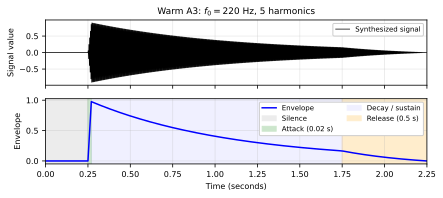

Warm A3


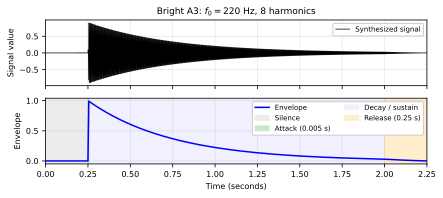

Bright A3


In [16]:
exercise_sound_design()

<div>
<a href="https://opensource.org/licenses/MIT"><img src="data_layout/PCP_License.png" width=100% style="float: right;" alt="PCP License"></a>
</div>